# Burst Experiment — Simplified 3-Phase Pipeline

Three independent phases:
1. **Pretrain** — train on background tasks until convergence (run once)
2. **Finetune** — burst phase with configurable concentration (sweep here)
3. **Forget** — reversion phase, measure how quickly burst knowledge is lost

Each phase saves checkpoints so you can re-run downstream phases without retraining upstream.

In [ ]:
import sys, os
os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")
from simple import make_data, pretrain, finetune, forget, report
import matplotlib.pyplot as plt
%matplotlib inline

OUT = "data/simple_burst"

## 1. Generate Data

One call, reuse across all phases. Adjust `depth`, `burst_pos`, `n_a` to change task complexity.

In [2]:
data = make_data(depth=3, burst_pos=3, n_a=4)
print(f"Vocab: {data['vocab_size']}, Context: {data['context_size']}, Prompt: {data['prompt_len']}")
print(f"Other tasks: {data['task_info']['n_other_tasks']}, Burst tasks: {data['task_info']['n_burst_tasks']}")

Vocab: 37, Context: 37, Prompt: 12
Other tasks: 64, Burst tasks: 16


## 2. Pretrain (run once)

Trains on background data until acc_other >= 0.99. Saves checkpoint to reuse.

Pretrain:   0%|          | 0/600 [00:00<?, ?it/s]

Pretrain done: peak acc_other=0.8594, final loss_other=0.6663


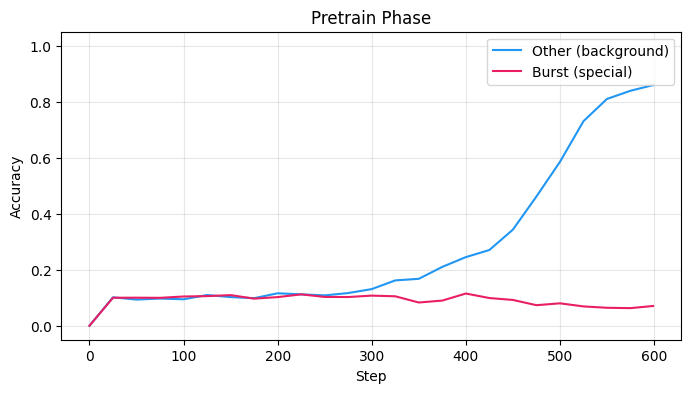

Checkpoint: data/simple_burst/pretrain/pretrain_ckpt.pt


In [ ]:
pt = pretrain(data, f"{OUT}/pretrain")
report.plot_pretrain(pt)
plt.show()
print(f"Checkpoint: {pt['ckpt_path']}")

## 3. Finetune — sweep over burst fractions

Each run loads the same pretrained checkpoint. Edit `FRACS` to test different concentrations.

Finetune burst_100:   0%|          | 0/200 [00:00<?, ?it/s]

  burst_100: peak_burst=1.000


Finetune burst_50:   0%|          | 0/200 [00:00<?, ?it/s]

  burst_50: peak_burst=0.999


Finetune burst_25:   0%|          | 0/200 [00:00<?, ?it/s]

  burst_25: peak_burst=0.996


Finetune burst_10:   0%|          | 0/200 [00:00<?, ?it/s]

  burst_10: peak_burst=0.942


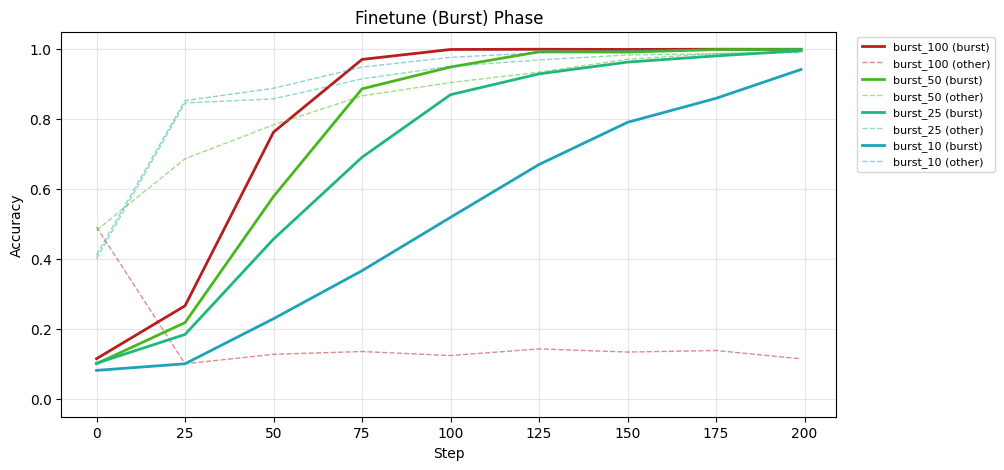

In [4]:
FRACS = [1.0, 0.5, 0.25, 0.10]  # sweep these

ft_results = []
for frac in FRACS:
    r = finetune(data, pt["ckpt_path"], f"{OUT}/finetune",
                 burst_frac=frac, steps=200)
    ft_results.append(r)
    print(f"  {r['tag']}: peak_burst={r['peak_burst']:.3f}")

report.plot_finetune(ft_results)
plt.show()

## 4. Forget — measure reversion for each finetuned model

Forget burst_100:   0%|          | 0/300 [00:00<?, ?it/s]

  burst_100: peak=1.000 -> end=0.134 (drop 86.6%)


Forget burst_50:   0%|          | 0/300 [00:00<?, ?it/s]

  burst_50: peak=0.999 -> end=0.154 (drop 84.5%)


Forget burst_25:   0%|          | 0/300 [00:00<?, ?it/s]

  burst_25: peak=0.996 -> end=0.156 (drop 84.4%)


Forget burst_10:   0%|          | 0/300 [00:00<?, ?it/s]

  burst_10: peak=0.942 -> end=0.181 (drop 80.8%)


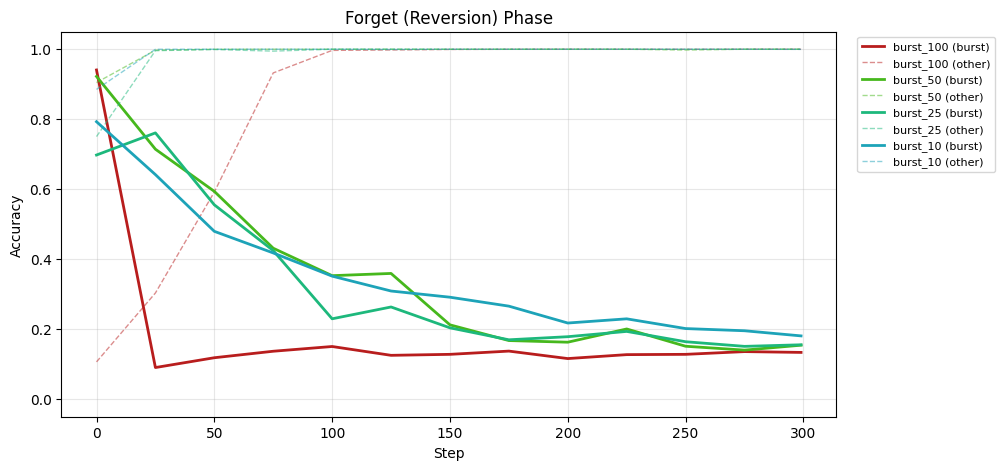

In [5]:
fg_results = []
for ft in ft_results:
    r = forget(data, ft["ckpt_path"], f"{OUT}/forget", steps=300)
    fg_results.append(r)
    print(f"  {r['tag']}: peak={r['peak_burst']:.3f} -> end={r['end_burst_acc']:.3f} "
          f"(drop {r['dropoff_pct']:.1f}%)")

report.plot_forget(fg_results)
plt.show()

## 5. Report

In [6]:
# Summary table
rows = report.summary_table(ft_results, fg_results)

Tag             Burst%   Peak    End  Drop%      AUC 95%-life 80%-life
----------------------------------------------------------------------
burst_100         100%  1.000  0.134   86.6       48    0.000   25.000
burst_50           50%  0.999  0.154   84.5      100    0.000   25.000
burst_25           25%  0.996  0.156   84.4       93    0.000    0.000
burst_10           10%  0.942  0.181   80.8      102    0.000   25.000


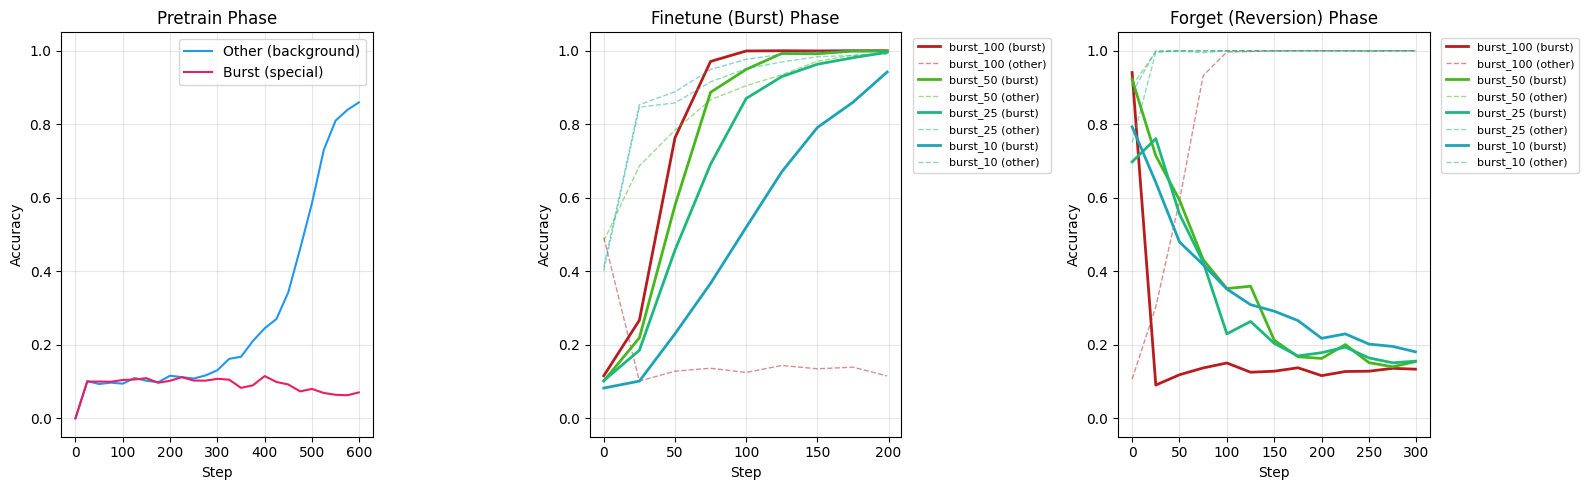

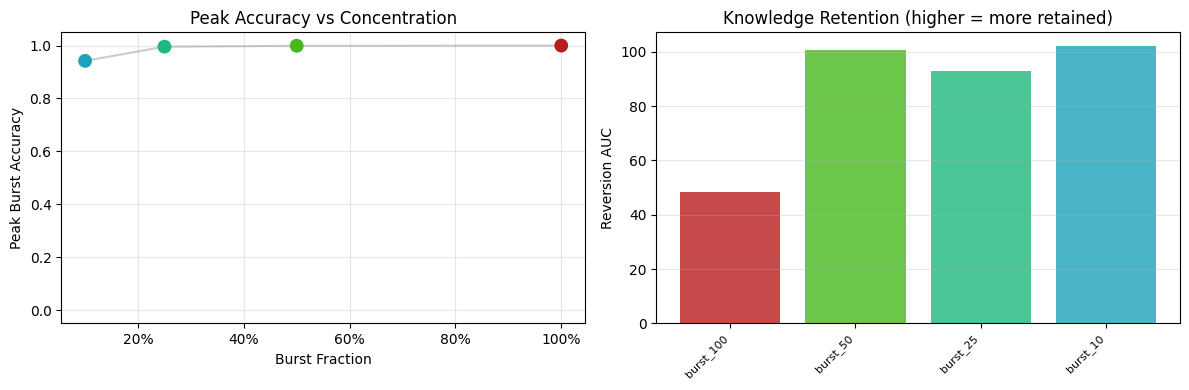

In [7]:
# Full trajectory + comparison charts
fig = report.plot_full_trajectory(pt, ft_results, fg_results)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
report.plot_peak_vs_frac(ft_results, axes[0])
report.plot_retention_vs_frac(fg_results, axes[1])
fig.tight_layout()
plt.show()

In [8]:
# Save all charts to disk
report.save_report(pt, ft_results, fg_results, f"{OUT}/report")

Report saved to data/simple_burst/report
